# 01_eda: Prior + Observation exploratory data analysis

**Date:** 2026-05-14 (Thursday)

Understand the **Prior** (LOVECLIM dense glacial-period simulation) and the **Observation** (Liu 26 pollen-based reconstructions) datasets before building the autoencoder.

1. Land/sea/ice mask of Prior: % valid cells and constancy across ages.
2. Distribution of `mtco`, `mtwa`: histograms, climatology maps, std maps.
3. Observation sparsity over time: sites per age.
4. Spatial bias of observations: map of all unique sites.
5. D-O event temporal coverage: Prior + Obs ages on a timeline (D–O windows shaded).
6. Prior-Obs residuals at co-located points.
7. Lag-1 temporal autocorrelation of Prior.
8. mtco↔mtwa per-cell correlation map.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
sys.path.insert(0, os.path.abspath(".."))  # allow `from paleoreco...` when run from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from paleoreco.data import (
    build_prior_cube,
    verify_mask_constant_across_ages,
    GRID_SHAPE,
    VARS,
)
from paleoreco.splits import DO_EVENT_WINDOWS

plt.rcParams["figure.dpi"] = 110

In [2]:
prior = build_prior_cube(
    prior_csv="../data/Prior.csv",
    cache_path="../data/cache/prior_cube.npz",
)
cube = prior["cube"]
ages = prior["ages"]
lats = prior["lats"]
lons = prior["lons"]
valid = prior["valid"]

print(f"cube shape : {cube.shape}, dtype {cube.dtype}")
print(f"N ages     : {len(ages)}  (range {ages.min()}..{ages.max()} yr BP)")
print(f"grid       : {len(lats)} lat x {len(lons)} lon")
print(f"lat range  : {lats.min()} .. {lats.max()}")
print(f"lon range  : {lons.min()} .. {lons.max()}")

cube shape : (804, 2, 32, 64), dtype float32
N ages     : 804  (range 29100..49175 yr BP)
grid       : 32 lat x 64 lon
lat range  : -84.375 .. 90.0
lon range  : -174.375 .. 180.0


## 1. Land/sea/ice mask of Prior

The Prior is LOVECLIM, a coupled atmosphere–ocean model whose `mtco` / `mtwa` are 2-metre air temperatures defined on **every** grid cell, ocean included. So we expect the geographic valid-mask to be uniformly `True`.

We also test whether the set of valid cells changes across the 804 ages.

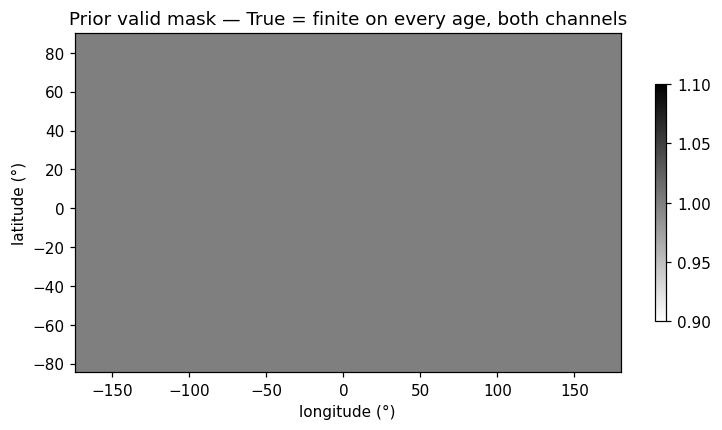

% valid cells : 100.00%   (2048 / 2048)
Mask constant across ages? True


In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(
    valid,
    origin="lower",
    extent=[lons.min(), lons.max(), lats.min(), lats.max()],
    cmap="gray_r",
    aspect="auto",
)
ax.set_xlabel("longitude (°)")
ax.set_ylabel("latitude (°)")
ax.set_title("Prior valid mask — True = finite on every age, both channels")
plt.colorbar(im, ax=ax, shrink=0.7)
plt.show()

print(f"% valid cells : {valid.mean() * 100:.2f}%   ({valid.sum()} / {valid.size})")
print(f"Mask constant across ages? {verify_mask_constant_across_ages(cube)}")

## 2. Distribution of `mtco`, `mtwa`

Three things per channel:

- **Histogram** over all (age, valid-cell) pairs, raw distribution of values the AE will be asked to reconstruct.
- **Climatology map**: per-cell mean across all 804 ages. Shows where it is reliably cold / warm.
- **Per-cell std map**: how much temperature varies over the 49-29 ka window at each cell. High std = the cell does interesting things during D-O events; low std = cell that barely changes (e.g. permanent ice, the case our `safe_valid` mask is designed to catch).


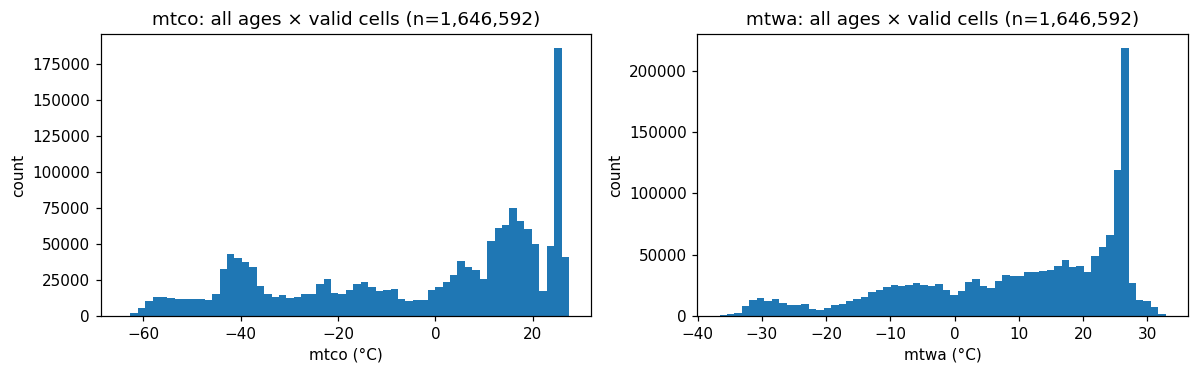

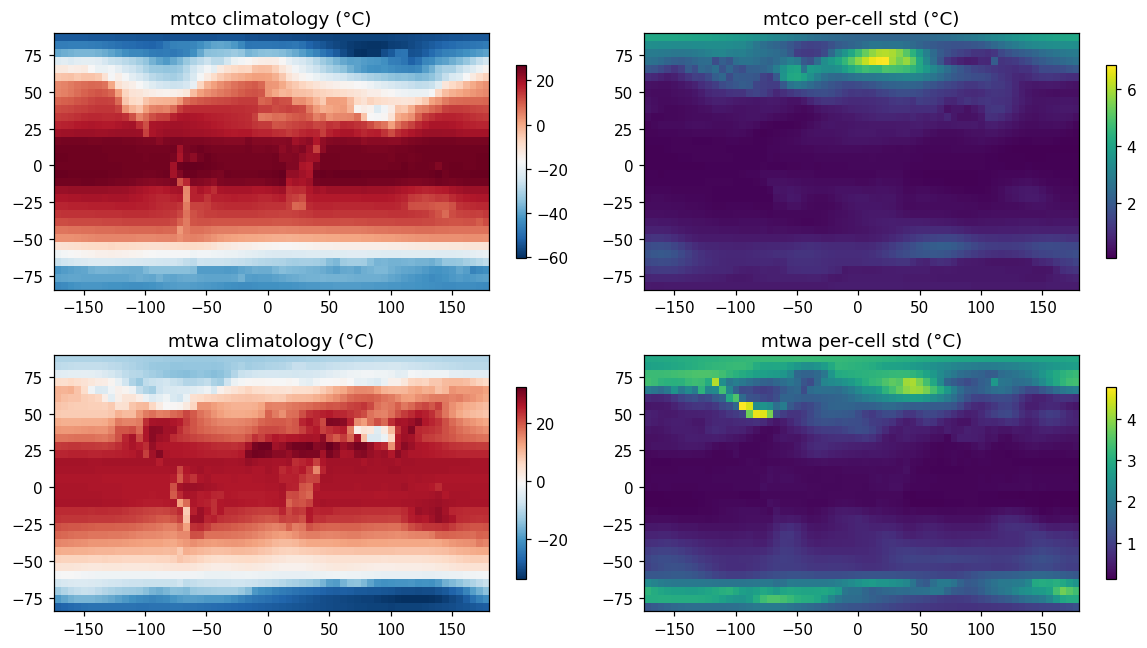

mtco: per-cell mean range  -60.3 ..  26.9 °C, median per-cell std 0.58 °C
mtwa: per-cell mean range  -33.9 ..  32.2 °C, median per-cell std 0.73 °C


In [4]:
mean_all = cube.mean(axis=0)  # (2, n_lat, n_lon)
std_all  = cube.std(axis=0)

# Histograms over all (age, cell) pairs, restricted to valid cells.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for c, name in enumerate(VARS):
    flat = cube[:, c][:, valid].ravel()
    axes[c].hist(flat, bins=60)
    axes[c].set_xlabel(f"{name} (°C)")
    axes[c].set_ylabel("count")
    axes[c].set_title(f"{name}: all ages × valid cells (n={flat.size:,})")
plt.tight_layout()
plt.show()

# Climatology + std maps. NaN out invalid cells for visual clarity.
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for c, name in enumerate(VARS):
    m = np.where(valid, mean_all[c], np.nan)
    s = np.where(valid, std_all[c],  np.nan)
    extent = [lons.min(), lons.max(), lats.min(), lats.max()]

    im0 = axes[c, 0].imshow(m, origin="lower", extent=extent, cmap="RdBu_r", aspect="auto")
    axes[c, 0].set_title(f"{name} climatology (°C)")
    plt.colorbar(im0, ax=axes[c, 0], shrink=0.75)

    im1 = axes[c, 1].imshow(s, origin="lower", extent=extent, cmap="viridis", aspect="auto")
    axes[c, 1].set_title(f"{name} per-cell std (°C)")
    plt.colorbar(im1, ax=axes[c, 1], shrink=0.75)
plt.tight_layout()
plt.show()

for c, name in enumerate(VARS):
    cell_min = mean_all[c][valid].min()
    cell_max = mean_all[c][valid].max()
    cell_std = float(np.median(std_all[c][valid]))
    print(f"{name}: per-cell mean range {cell_min:6.1f} .. {cell_max:5.1f} °C, median per-cell std {cell_std:.2f} °C")

## 3. Observation sparsity over time

How many proxy sites are reported per age in `Observation.csv`? The autoencoder does not see the observations during training, but the downstream generative model will be conditioned on them, so we need to know how sparse the conditioning signal is at any given time step.

Total observation rows : 63,823
Unique observation ages: 768
Sites per age — min 4, median 87, mean 83.1, max 118


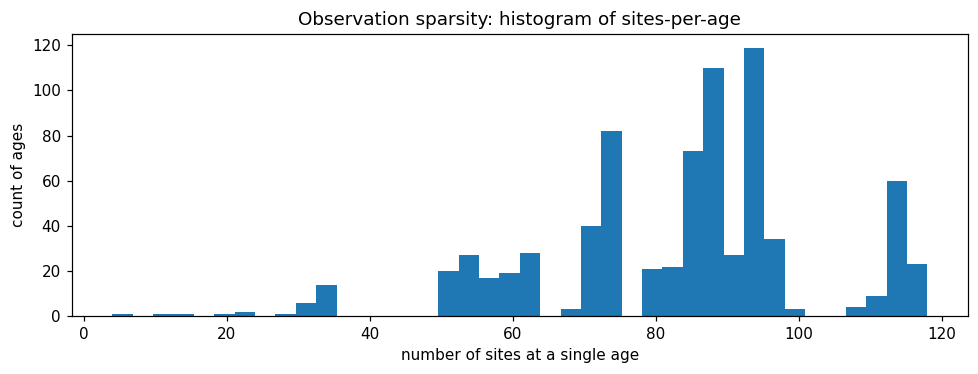

In [5]:
obs = pd.read_csv(
    "../data/Observation.csv",
    usecols=["age", "latitude", "longitude", "mtco", "mtwa", "sse_mtco", "sse_mtwa"],
)
n_per_age = obs.groupby("age").size()

print(f"Total observation rows : {len(obs):,}")
print(f"Unique observation ages: {n_per_age.size}")
print(
    f"Sites per age — min {n_per_age.min()}, "
    f"median {n_per_age.median():.0f}, "
    f"mean {n_per_age.mean():.1f}, "
    f"max {n_per_age.max()}"
)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(n_per_age.values, bins=40)
ax.set_xlabel("number of sites at a single age")
ax.set_ylabel("count of ages")
ax.set_title("Observation sparsity: histogram of sites-per-age")
plt.tight_layout()
plt.show()

## 4. Spatial bias of observations

Pollen-based proxies cluster heavily in the Northern Hemisphere / Eurasia (cf. Liu 26 Fig. 1b). Visualising every unique site location gives a quick sense of where the eventual conditional model will be receiving information and where it will have to extrapolate.

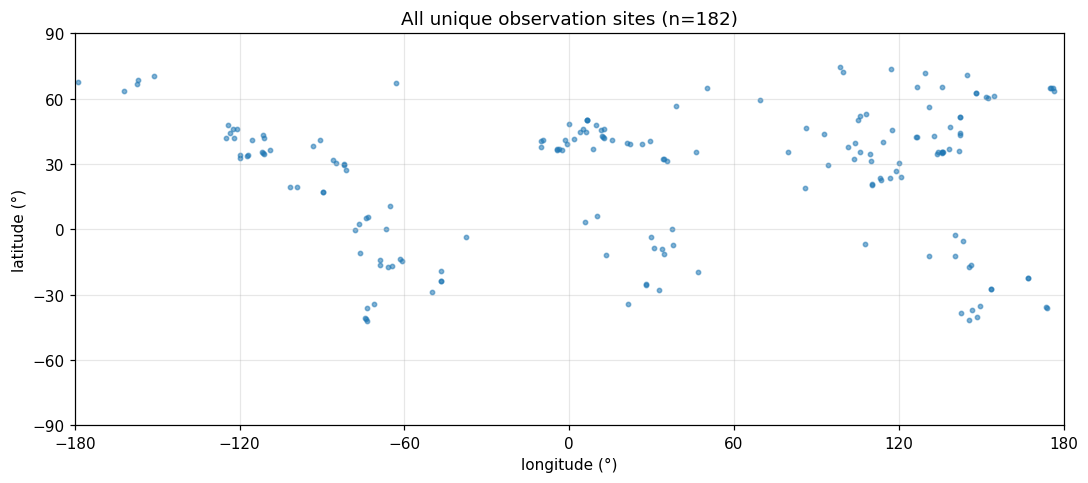

NH sites: 135  (74.2%)
SH sites: 47  (25.8%)


In [6]:
unique_sites = obs[["latitude", "longitude"]].drop_duplicates()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.scatter(unique_sites["longitude"], unique_sites["latitude"], s=8, alpha=0.55)
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xticks(np.arange(-180, 181, 60))
ax.set_yticks(np.arange(-90, 91, 30))
ax.set_xlabel("longitude (°)")
ax.set_ylabel("latitude (°)")
ax.set_title(f"All unique observation sites (n={len(unique_sites)})")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

nh = int((unique_sites["latitude"] >  0).sum())
sh = int((unique_sites["latitude"] <= 0).sum())
print(f"NH sites: {nh}  ({nh / len(unique_sites) * 100:.1f}%)")
print(f"SH sites: {sh}  ({sh / len(unique_sites) * 100:.1f}%)")

## 5. D-O event temporal coverage

Plot every Prior age and every Observation age on a single timeline, with the eight D-O event windows shaded as grey bands. The shading uses the `[start − 300, start + 600]` analysis windows from `paleoreco/splits.py`, which trace back to Rasmussen 2014 / Wolff 2010 start ages on the AICC2012 timescale.

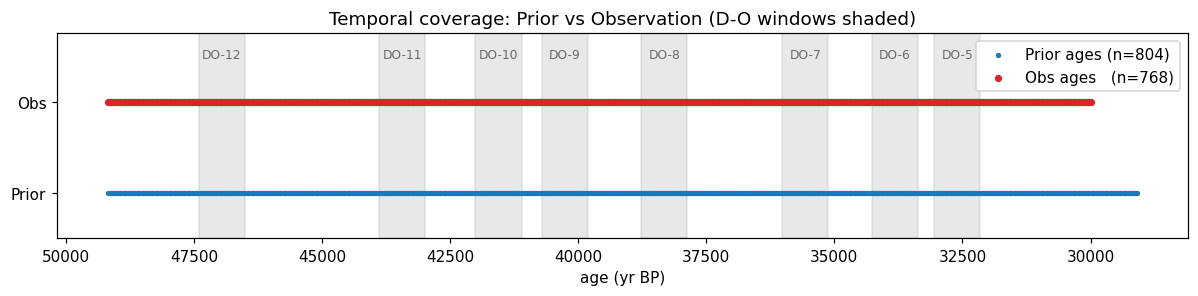

Obs ages inside Prior window : 768 / 768
Prior step (median delta age): 25 yr
Obs   step (median delta age): 25 yr


In [7]:
obs_ages = np.sort(obs["age"].unique())

fig, ax = plt.subplots(figsize=(11, 2.8))

# Shade D-O event windows first so they sit underneath the scatter.
for ev, (lo, hi) in DO_EVENT_WINDOWS.items():
    ax.axvspan(lo, hi, alpha=0.18, color="gray")
    ax.text((lo + hi) / 2, 1.45, f"DO-{ev}", ha="center", va="bottom",
            fontsize=8, color="dimgray")

ax.scatter(ages,     np.zeros_like(ages),     s=6,  label=f"Prior ages (n={len(ages)})",     color="C0")
ax.scatter(obs_ages, np.ones_like(obs_ages),  s=14, label=f"Obs ages   (n={len(obs_ages)})", color="C3")
ax.set_yticks([0, 1])
ax.set_yticklabels(["Prior", "Obs"])
ax.set_ylim(-0.5, 1.75)
ax.set_xlabel("age (yr BP)")
ax.set_title("Temporal coverage: Prior vs Observation (D-O windows shaded)")
ax.invert_xaxis()  # convention: younger ages on the right
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

in_prior_window = int(((obs_ages >= ages.min()) & (obs_ages <= ages.max())).sum())
print(f"Obs ages inside Prior window : {in_prior_window} / {len(obs_ages)}")
print(f"Prior step (median delta age): {int(np.median(np.diff(ages)))} yr")
print(f"Obs   step (median delta age): {int(np.median(np.diff(obs_ages)))} yr")

## 6. Prior-Obs residuals at co-located points

For each observation row, find the Prior cell (nearest grid cell × nearest age) and compute `prior - obs` for each temperature channel. If the residuals centre near zero, the Prior is unbiased relative to reconstructions; large positive or negative means the eventual conditional model will need to correct the Prior toward the observations.

Obs rows inside Prior age window : 63,823 / 63,823


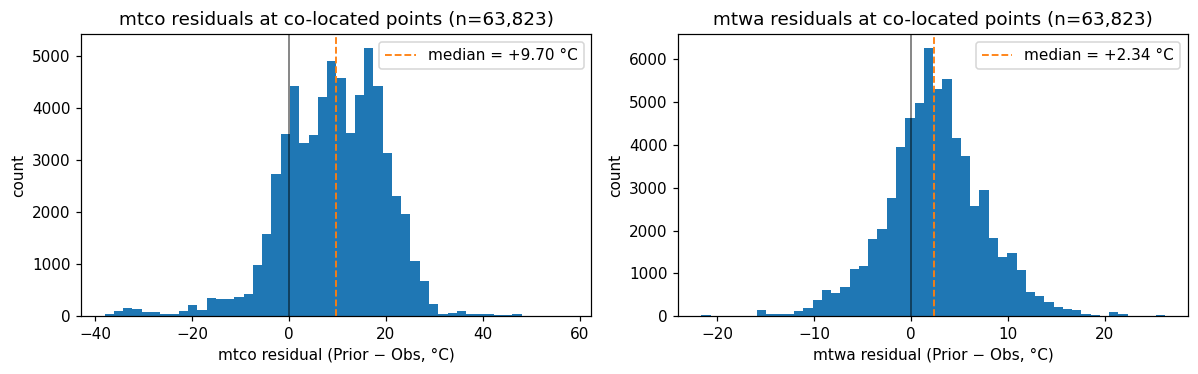

mtco: median=+9.70 °C, MAD=7.34 °C, 5–95% range=[-6.6, +24.1] °C
mtwa: median=+2.34 °C, MAD=2.97 °C, 5–95% range=[-6.0, +10.9] °C


In [8]:
def snap_idx(values, axis):
    """For each value, return the index of the nearest entry of axis (sorted ascending)."""
    idx = np.searchsorted(axis, values)
    idx = np.clip(idx, 1, len(axis) - 1)
    left = axis[idx - 1]
    right = axis[idx]
    return np.where(values - left < right - values, idx - 1, idx)

# Keep only obs whose age falls inside the Prior age range.
obs_in = obs[(obs["age"] >= ages.min()) & (obs["age"] <= ages.max())].copy()
print(f"Obs rows inside Prior age window : {len(obs_in):,} / {len(obs):,}")

age_idx = snap_idx(obs_in["age"].to_numpy(),       ages)
lat_idx = snap_idx(obs_in["latitude"].to_numpy(),  lats)
lon_idx = snap_idx(obs_in["longitude"].to_numpy(), lons)

prior_mtco = cube[age_idx, 0, lat_idx, lon_idx]
prior_mtwa = cube[age_idx, 1, lat_idx, lon_idx]

resid_mtco = prior_mtco - obs_in["mtco"].to_numpy()
resid_mtwa = prior_mtwa - obs_in["mtwa"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax_, resid, name in zip(axes, [resid_mtco, resid_mtwa], ["mtco", "mtwa"]):
    med = float(np.median(resid))
    ax_.hist(resid, bins=50)
    ax_.axvline(0, color="k", lw=1, alpha=0.6)
    ax_.axvline(med, color="C1", lw=1.2, ls="--", label=f"median = {med:+.2f} °C")
    ax_.set_xlabel(f"{name} residual (Prior − Obs, °C)")
    ax_.set_ylabel("count")
    ax_.set_title(f"{name} residuals at co-located points (n={len(resid):,})")
    ax_.legend()
plt.tight_layout()
plt.show()

for resid, name in zip([resid_mtco, resid_mtwa], ["mtco", "mtwa"]):
    med = float(np.median(resid))
    mad = float(np.median(np.abs(resid - med)))
    p05, p95 = np.percentile(resid, 5), np.percentile(resid, 95)
    print(
        f"{name}: median={med:+.2f} °C, MAD={mad:.2f} °C, "
        f"5–95% range=[{p05:+.1f}, {p95:+.1f}] °C"
    )

## 7. Lag-1 temporal autocorrelation of Prior

For each cell, compute the correlation between consecutive ages in the sorted age sequence. High autocorrelation (close to 1) means consecutive Prior snapshots are nearly identical - which would mean our `splits.py` default of "between-event ages → train" contains many highly correlated samples (i.e. the *effective* training set is smaller than the 742 nominal ages).

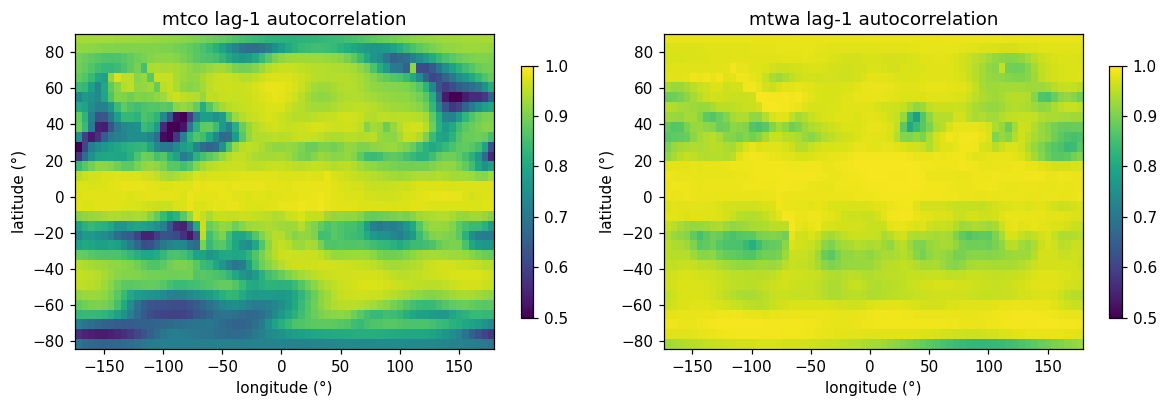

mtco: median r1=0.897, 5–95% range=[0.655, 0.976]
mtwa: median r1=0.970, 5–95% range=[0.890, 0.990]


In [9]:
def lag1_autocorr_map(cube_ch):
    """Cell-by-cell lag-1 autocorrelation along the age axis.

    cube_ch: (N, H, W). Returns (H, W) array of lag-1 autocorrelations
    using the biased estimator r1 = sum(x[:-1] * x[1:]) / sum(x ** 2).
    """
    x = cube_ch - cube_ch.mean(axis=0, keepdims=True)
    num = (x[:-1] * x[1:]).sum(axis=0)
    den = (x ** 2).sum(axis=0)
    return num / np.where(den > 0, den, 1.0)

r1_mtco = lag1_autocorr_map(cube[:, 0])
r1_mtwa = lag1_autocorr_map(cube[:, 1])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
extent = [lons.min(), lons.max(), lats.min(), lats.max()]
for ax_, r1, name in zip(axes, [r1_mtco, r1_mtwa], ["mtco", "mtwa"]):
    im = ax_.imshow(
        np.where(valid, r1, np.nan),
        origin="lower", extent=extent,
        cmap="viridis", vmin=0.5, vmax=1.0, aspect="auto",
    )
    ax_.set_title(f"{name} lag-1 autocorrelation")
    ax_.set_xlabel("longitude (°)")
    ax_.set_ylabel("latitude (°)")
    plt.colorbar(im, ax=ax_, shrink=0.8)
plt.tight_layout()
plt.show()

for r1, name in zip([r1_mtco, r1_mtwa], ["mtco", "mtwa"]):
    v = r1[valid]
    print(
        f"{name}: median r1={np.median(v):.3f}, "
        f"5–95% range=[{np.percentile(v, 5):.3f}, {np.percentile(v, 95):.3f}]"
    )

## 8. mtco/mtwa per-cell correlation

For each cell, compute the Pearson correlation across all 804 ages between `mtco` and `mtwa`.

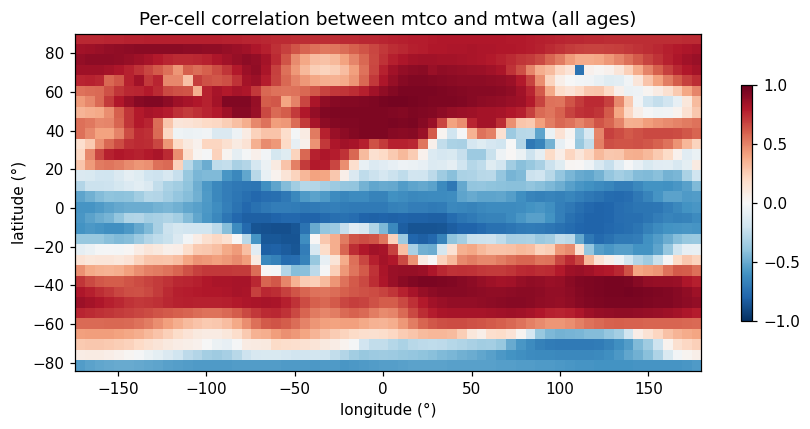

Per-cell mtco↔mtwa correlation: median=0.361, 5–95% range=[-0.718, 0.908]
Cells with |corr| > 0.9: 119 / 2048 (5.8%)


In [10]:
a = cube[:, 0] - cube[:, 0].mean(axis=0, keepdims=True)
b = cube[:, 1] - cube[:, 1].mean(axis=0, keepdims=True)
num = (a * b).sum(axis=0)
den = np.sqrt((a ** 2).sum(axis=0) * (b ** 2).sum(axis=0))
corr_map = num / np.where(den > 0, den, 1.0)

fig, ax = plt.subplots(figsize=(8, 4))
extent = [lons.min(), lons.max(), lats.min(), lats.max()]
im = ax.imshow(
    np.where(valid, corr_map, np.nan),
    origin="lower", extent=extent,
    cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto",
)
ax.set_title("Per-cell correlation between mtco and mtwa (all ages)")
ax.set_xlabel("longitude (°)")
ax.set_ylabel("latitude (°)")
plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

v = corr_map[valid]
print(
    f"Per-cell mtco↔mtwa correlation: median={np.median(v):.3f}, "
    f"5–95% range=[{np.percentile(v, 5):.3f}, {np.percentile(v, 95):.3f}]"
)
high = float((np.abs(v) > 0.9).mean()) * 100
print(f"Cells with |corr| > 0.9: {(np.abs(v) > 0.9).sum()} / {v.size} ({high:.1f}%)")